### 使用 uproot 读取 ROOT 数据


In [2]:
import numpy as np
import uproot

with uproot.open("FitGaussData.root") as root_file:
    tree = root_file["tree"] #读取ROOT文件的树 TTree *tree = (TTree*)file->Get("tree");
    branches = tree.arrays(["EventID", "Ex"], library="np") #读取root文件中的三个branch，并转化为np结构的数据

data = np.column_stack((branches["EventID"], branches["Ex"])) #column_stack 的意思是把三个branch的数据按列排布

print(f"{'EventID':>12} {'Ex':>12} ")
for EventID, Ex in data[:10]: #只打印前10个事件
    print(f"{EventID:12.6f} {Ex:12.6f} ")

     EventID           Ex 
    0.000000   984.490170 
    1.000000  1311.111501 
    2.000000   973.553630 
    3.000000  1378.322463 
    4.000000   914.071812 
    5.000000  1253.482080 
    6.000000  1327.251999 
    7.000000  1051.549204 
    8.000000  1567.643961 
    9.000000  1341.597292 


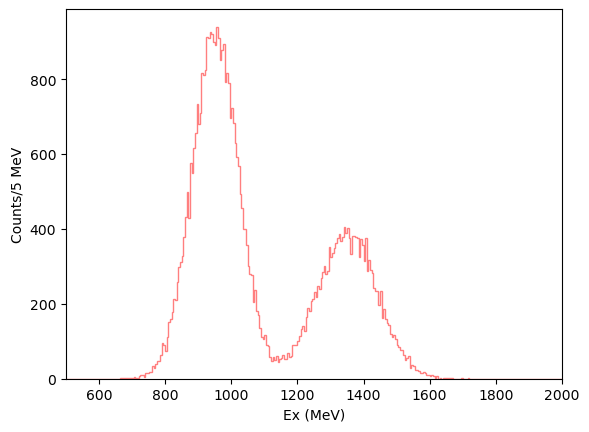

In [3]:
import numpy as np
import matplotlib.pyplot as plt

Ex = branches["Ex"]
xmin = 500
xmax = 2000
bin_width = 5.0
bins = np.arange(xmin, xmax + bin_width, bin_width)
plt.hist(Ex,bins=bins,histtype="step",color="red",linewidth=1,alpha=0.5)

plt.xlabel("Ex (MeV)")
plt.ylabel(f"Counts/{bin_width:g} MeV")

plt.xlim(xmin, xmax)
plt.show()

使用uproot写入root文件

In [ ]:
# 计算新的 Ex
ExNew = branches["Ex"] / 5.0

# 显式创建 TTree，并写入数据
with uproot.recreate("ExNew.root") as root_file:
    #定义树的结构
    tree = root_file.mktree(
        "tree",
        {
            "EventID": branches["EventID"].dtype,
            "Ex": branches["Ex"].dtype,
            "ExNew": ExNew.dtype,
        },
        title="simple event tree",
    )
    #向树里面填数据
    tree.extend({
        "EventID": branches["EventID"],
        "Ex": branches["Ex"],
        "ExNew": ExNew,
    })

print("ExNew.root 写入完成")

ExNew.root 写入完成
